# St. Maarten Mobility Map Using Graph Structures

<p>Script 1: Ingesting Networkx/OSMnx MultiDiGraph data</p>

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import osmnx as ox

##### Script 2: Mobility graph base metrics

In [2]:
# Load the graph from a pickle file
graph_pickle_path = "/home/mzero/main/repo/fio_projects/caribbean_automated_systems/fio_caribbean_mobility_graph/mobility_graph_lab/data/processed/base/graph.gpickle"

with open(graph_pickle_path, "rb") as f:
  G = pickle.load(f)

print("Type:", type(G))
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("CRS:", G.graph.get("crs"))
print("Directed:", G.is_directed())
print("Multigraph:", G.is_multigraph())

Type: <class 'networkx.classes.multidigraph.MultiDiGraph'>
Nodes: 1961
Edges: 4419
CRS: epsg:4326
Directed: True
Multigraph: True


In [3]:
nodes_gdf, edges_gdf = ox.convert.graph_to_gdfs(G)

display(nodes_gdf.head())
display(edges_gdf.head())

,y,x,street_count,highway,geometry
osmid,,,,,
250652600,18.042546,-63.084156,3,NaN,POINT (-63.08416 18.04255)
250652602,18.041218,-63.083127,3,NaN,POINT (-63.08313 18.04122)
250652604,18.040132,-63.082159,3,NaN,POINT (-63.08216 18.04013)
250656101,18.034214,-63.077123,3,NaN,POINT (-63.07712 18.03421)
250656105,18.033682,-63.077215,3,NaN,POINT (-63.07721 18.03368)


osmid      highway  \
u         v           key                                                  
250652600 5319009556  0                           524083000      primary   
          303292044   0    [293416801, 27619117, 524074070]  residential   
          13076637177 0                           524083000      primary   
250652602 5119424612  0                           524215009      primary   
          4283156652  0    [429188881, 27619106, 524215005]  residential   

                          maxspeed             name  oneway reversed  \
u         v           key                                              
250652600 5319009556  0         30       Union Road   False     True   
          303292044   0        NaN  Peter John Road   False    False   
          13076637177 0         30       Union Road   False    False   
250652602 5119424612  0         30       Union Road   False     True   
          4283156652  0        NaN  Madeleine Drive   False    False   

                               length  speed_kph  travel_time         t0  \
u         v           key                                                  
250652600 5319009556  0     66.957787  30.000000     8.034934   8.034934   
          303292044   0    259.567168  30.413223    30.724853  30.724853   
          13076637177 0     33.904223  30.000000     4.068507   4.068507   
250652602 5119424612  0     39.620568  30.000000     4.754468   4.754468   
          4283156652  0    524.258935  30.413223    62.056302  62.056302   

                           capacity  flow       time  \
u         v           key                              
250652600 5319009556  0      1400.0   0.0   8.034934   
          303292044   0       600.0   0.0  30.724853   
          13076637177 0      1400.0   0.0   4.068507   
250652602 5119424612  0      1400.0   0.0   4.754468   
          4283156652  0       600.0   0.0  62.056302   

                                                                    geometry  \
u         v           key                                                      
250652600 5319009556  0    LINESTRING (-63.08416 18.04255, -63.08378 18.0...   
          303292044   0    LINESTRING (-63.08416 18.04255, -63.08345 18.0...   
          13076637177 0    LINESTRING (-63.08416 18.04255, -63.08421 18.0...   
250652602 5119424612  0    LINESTRING (-63.08313 18.04122, -63.0829 18.04...   
          4283156652  0    LINESTRING (-63.08313 18.04122, -63.0836 18.04...   

                          lanes bridge junction access  
u         v           key                               
250652600 5319009556  0     NaN    NaN      NaN    NaN  
          303292044   0     NaN    NaN      NaN    NaN  
          13076637177 0     NaN    NaN      NaN    NaN  
250652602 5119424612  0     NaN    NaN      NaN    NaN  
          4283156652  0     NaN    NaN      NaN    NaN

In [4]:
#  Showcase nodes and edges with their attributes
for node in list(G.nodes(data=True))[:10]:
    print(f"Node: {node}")


for u, v, key, data in list(G.edges(keys=True, data=True))[:10]:
    print(
        f"u: {u}, v: {v}, key: {key}, name: {data.get('name')}, length: {data.get('length')}"
    )

Node: (250652600, {'y': 18.0425463, 'x': -63.084156, 'street_count': 3})
Node: (250652602, {'y': 18.0412185, 'x': -63.0831266, 'street_count': 3})
Node: (250652604, {'y': 18.040132, 'x': -63.082159, 'street_count': 3})
Node: (250656101, {'y': 18.0342141, 'x': -63.0771233, 'street_count': 3})
Node: (250656105, {'y': 18.0336824, 'x': -63.0772146, 'street_count': 3})
Node: (250656108, {'y': 18.0326049, 'x': -63.0786158, 'street_count': 3})
Node: (250656114, {'y': 18.0308199, 'x': -63.0808956, 'street_count': 3})
Node: (250656118, {'y': 18.029578, 'x': -63.0825108, 'highway': 'crossing', 'street_count': 3})
Node: (250656119, {'y': 18.0292124, 'x': -63.0829932, 'street_count': 3})
Node: (250656141, {'y': 18.0326566, 'x': -63.0906693, 'street_count': 3})
u: 250652600, v: 5319009556, key: 0, name: Union Road, length: 66.95778691406522
u: 250652600, v: 303292044, key: 0, name: Peter John Road, length: 259.56716751407384
u: 250652600, v: 13076637177, key: 0, name: Union Road, length: 33.9042226

In [5]:

# Testinging a specific node for incoming and outgoing edges
node_id = 250652600

print("Node attributes:")
print(G.nodes[node_id])

print("\nOutgoing road segments:")
for u, v, key, data in G.out_edges(node_id, keys=True, data=True):
    print(
        f"{u} -> {v}, key={key}, "
        f"name={data.get('name')}, "
        f"oneway={data.get('oneway')}, "
        f"length={data.get('length')}"
    )

print("\nIncoming road segments:")
for u, v, key, data in G.in_edges(node_id, keys=True, data=True):
    print(
        f"{u} -> {v}, key={key}, "
        f"name={data.get('name')}, "
        f"oneway={data.get('oneway')}, "
        f"length={data.get('length')}"
    )

Node attributes:
{'y': 18.0425463, 'x': -63.084156, 'street_count': 3}

Outgoing road segments:
250652600 -> 5319009556, key=0, name=Union Road, oneway=False, length=66.95778691406522
250652600 -> 303292044, key=0, name=Peter John Road, oneway=False, length=259.56716751407384
250652600 -> 13076637177, key=0, name=Union Road, oneway=False, length=33.904222613423784

Incoming road segments:
303292044 -> 250652600, key=0, name=Peter John Road, oneway=False, length=259.56716751407384
5319009556 -> 250652600, key=0, name=Union Road, oneway=False, length=66.95778691406522
13076637177 -> 250652600, key=0, name=Union Road, oneway=False, length=33.904222613423784


##### Script 2: Mobility Graph Analysis

<p>These are are somethings we want to identify on our road network.</p>

<ol>
  <li>Bottleneck mapping</li>
  <li>Congestion mapping</li>
  <li>Third item
    <ol>
      <li>Indented item</li>
      <li>Indented item</li>
    </ol>
  </li>
  <li>Fourth item</li>
</ol>

##### Script 2: Graph analysis visualization

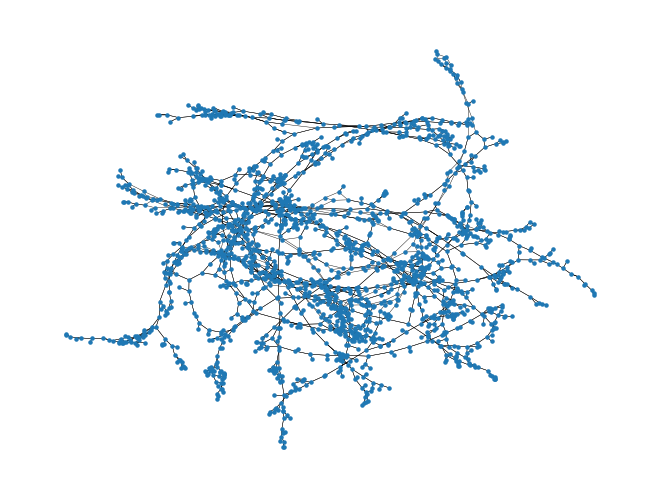

In [6]:
import matplotlib.pyplot as plt
import networkx as nx

positions = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos=positions,
    node_size=5,
    width=0.3,
    arrows=False,
)

plt.show()

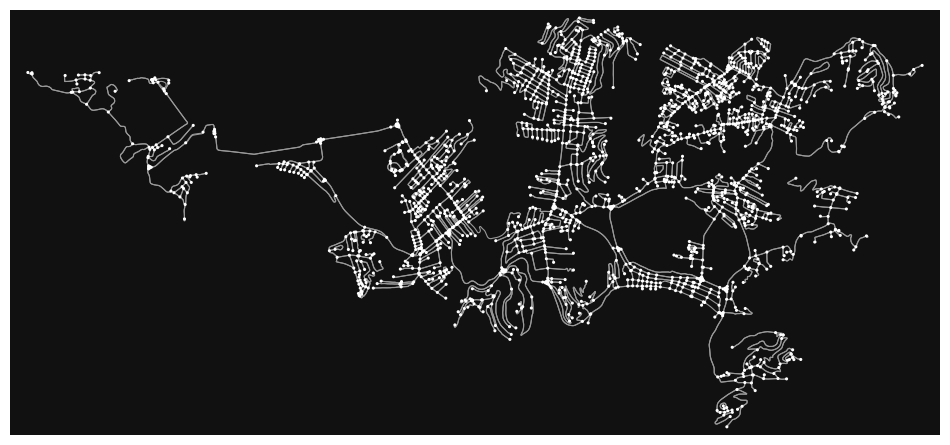

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [8]:

ox.plot_graph(
    G,
    node_size=5,
    edge_linewidth=0.8,
    figsize=(12, 12),
)